In [ ]:
from pathlib import Path
import pandas as pd
import glob
import unicodedata
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir la ruta base del proyecto relativea este notebook
# Estructura: hackODS/dashboard/HackODS.ipynb -> parent.parent = hackODS/
PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in locals() else Path.cwd().parent.parent
if not PROJECT_ROOT.exists():
    # Si no se puede resolver, usar ruta relativa
    PROJECT_ROOT = Path('../..').resolve()

BASE_DIR = PROJECT_ROOT / 'data' / 'resultados'

print(f"Ruta base detectada: {BASE_DIR}")
if not BASE_DIR.exists():
    print(f"ADVERTENCIA: No se encontró la carpeta en {BASE_DIR}. Verifica que los archivos estén en ../data/resultados/")
else:
    print(f"Carpeta de datos detectada con éxito.")

Mounted at /content/drive
Carpeta HackODS detectada con éxito.


# NARRATIVA: Resiliencia de la Infraestructura Educativa frente al Cambio Climático

## Cómo ejecutar este notebook

1. Asegúrate de que los archivos procesados existan en `../data/resultados/`:
   - `matricula_unificada_final.csv`
   - `atlas_datos_unificado.xlsx`
   - `clima_municipal.csv`

2. Ejecuta las celdas en orden. Las visualizaciones se mostrarán en el navegador.

3. El notebook genera un análisis completo con dos partes:
   - **NARRATIVA**: Estructura con secciones (Problema → Datos → Análisis → Conclusiones)
   - **VISUALIZACIONES**: Gráficos de temperatura, infraestructura, y vulnerabilidad térmica

In [52]:


# Configuración de rutas
ruta_matricula = BASE_DIR / "matricula_unificada_final.csv"
ruta_atlas = BASE_DIR / "atlas_datos_unificado.xlsx" # Tu archivo del Atlas

# 1. Cargar bases de datos
df_mat = pd.read_csv(ruta_matricula)
# Asegurar que la clave de municipio sea string con ceros a la izquierda
df_mat['cve_mun_full'] = df_mat['cve_mun_full'].astype(str).str.zfill(5)

# Cargar Atlas (Asumiendo que tienes una columna 'tipo' para diferenciar 'edu' e 'inf')
df_atlas_raw = pd.read_excel(ruta_atlas)

# 1. Mapeo de nombres reales para las columnas placeholder (V1, V2...)
# Basado en la estructura oficial que proporcionaste:

cols_educacion = {
    'CVEGEO': 'cve_mun_full',
    'V1': 'no_asistencia_3_5_pct',
    'V2': 'no_asistencia_6_11_pct',
    'V3': 'no_asistencia_12_14_pct',
    'V4': 'asistencia_15_17_pct',
    'V5': 'analfabetismo_pct',
    'V6': 'grado_escolaridad',
    'V7': 'marginacion'
}

cols_infraestructura = {
    'CVEGEO': 'cve_mun_full',
    'V1': 'electricidad_pct',
    'V2': 'computadoras_pct',
    'V3': 'internet_pct',
    'V4': 'infra_adaptada_pct',
    'V5': 'material_adaptado_pct',
    'V6': 'agua_potable_pct',
    'V7': 'lavabo_manos_pct',
    'V8': 'indice_infra_sep'
}

# 2. Separar el DataFrame original por tipo de tabla
# Asumiendo que tu df cargado se llama 'df_atlas_raw'
df_edu_raw = df_atlas_raw[df_atlas_raw['Tipo'] == 'edu'].copy()
df_inf_raw = df_atlas_raw[df_atlas_raw['Tipo'] == 'inf'].copy()

# 3. Renombrar columnas usando los diccionarios
df_edu = df_edu_raw.rename(columns=cols_educacion)[list(cols_educacion.values())]
df_inf = df_inf_raw.rename(columns=cols_infraestructura)[list(cols_infraestructura.values())]

# 4. Asegurar que las claves tengan el formato de 5 dígitos (01001) para el cruce
df_edu['cve_mun_full'] = df_edu['cve_mun_full'].astype(str).str.zfill(5)
df_inf['cve_mun_full'] = df_inf['cve_mun_full'].astype(str).str.zfill(5)

# 5. MERGE HORIZONTAL: Unir indicadores de Educación e Infraestructura por Municipio
df_atlas_final = pd.merge(df_edu, df_inf, on='cve_mun_full', how='inner')

# 6. Transformación Narrativa: Convertir inasistencia en asistencia para primaria
# Esto ayuda al storytelling de "Escuelas Resilientes"
df_atlas_final['asistencia_primaria_pct'] = 100 - df_atlas_final['no_asistencia_6_11_pct'].astype(float)

print("Dataset del Atlas unificado y renombrado con éxito.")
df_atlas_final.head()

Dataset del Atlas unificado y renombrado con éxito.


,cve_mun_full,no_asistencia_3_5_pct,no_asistencia_6_11_pct,no_asistencia_12_14_pct,asistencia_15_17_pct,analfabetismo_pct,grado_escolaridad,marginacion,electricidad_pct,computadoras_pct,internet_pct,infra_adaptada_pct,material_adaptado_pct,agua_potable_pct,lavabo_manos_pct,indice_infra_sep,asistencia_primaria_pct
0,01001,38.2,2.9,7.9,73.1,1.6,10.84,Muy bajo,99.6,76.5,86.6,59.8,31.7,98.9,98.5,0.8,97.1
1,01002,45.2,4.3,10.5,66.7,3.5,8.54,Muy bajo,100.0,71.6,74.1,39.5,8.6,93.8,98.8,0.7,95.7
2,01003,47.8,3.7,13.6,59.2,4.5,8.05,Muy bajo,97.6,72.0,64.6,42.7,26.8,91.5,95.1,0.7,96.3
3,01004,39.8,4.7,7.7,74.1,3.1,9.08,Muy bajo,100.0,94.7,89.5,68.4,21.1,100.0,94.7,0.8,95.3
4,01005,40.6,3.4,10.9,68.2,2.4,10.22,Muy bajo,100.0,65.5,84.5,55.5,28.2,95.5,95.5,0.7,96.6


In [ ]:
# Verificar que los archivos necesarios existan
print("=" * 60)
print("VALIDACIÓN DE ARCHIVOS REQUERIDOS")
print("=" * 60)

archivos_requeridos = {
    "matricula_unificada_final.csv": BASE_DIR / "matricula_unificada_final.csv",
    "atlas_datos_unificado.xlsx": BASE_DIR / "atlas_datos_unificado.xlsx",
    "clima_municipal.csv": BASE_DIR / "clima_municipal.csv"
}

archivos_faltantes = []
for nombre, ruta in archivos_requeridos.items():
    if ruta.exists():
        print(f"✓ {nombre}")
    else:
        print(f"✗ FALTA: {nombre}")
        archivos_faltantes.append(nombre)

if archivos_faltantes:
    print("\n⚠️  ADVERTENCIA: Faltan los siguientes archivos:")
    for arch in archivos_faltantes:
        print(f"   - {arch}")
    print("\nEjecuta los scripts de procesamiento en esta orden:")
    print("  1. python ../scripts/procesamiento_temperatura.py")
    print("  2. python ../scripts/procesamiento_temperatura2.py")
    print("  3. python ../scripts/matricula_procesamiento.py")
    print("  4. python ../scripts/procesamiento -copia.py")
else:
    print("\n✓ Todos los archivos requeridos están disponibles. Procediendo...")
print("=" * 60)

In [53]:


# 1. Cargar la Matrícula Nacional Unificada (el CSV de los 32 estados)
# Asegúrate de que el nombre del archivo coincida con el que guardaste
ruta_matricula = BASE_DIR / "matricula_unificada_final.csv"
df_mat = pd.read_csv(ruta_matricula)

# 2. Estandarizar la clave en la Matrícula para asegurar el cruce
# La llamamos igual que en el Atlas: 'cve_mun_full'
# Si en tu CSV se llama diferente, cámbialo aquí:
df_mat = df_mat.rename(columns={'cve_mun_full': 'cve_mun_full'})
df_mat['cve_mun_full'] = df_mat['cve_mun_full'].astype(str).str.zfill(5)

# 3. MERGE FINAL
# Unimos el Atlas con la Matrícula usando la clave de 5 dígitos
# Usamos 'left' para conservar todos los datos de infraestructura aunque falte alguna matrícula
df_proyecto = pd.merge(df_atlas_final, df_mat, on='cve_mun_full', how='left')

# 4. Creación de Indicadores de Impacto (Storytelling de Datos)
# Hacinamiento: Alumnos por escuela (promedio municipal)
df_proyecto['alumnos_por_escuela'] = df_proyecto['Alumnos'] / df_proyecto['Escuelas']

# 5. Guardar el Master Dataset
df_proyecto.to_csv('master_dataset_escuelas_resilientes.csv', index=False, encoding='utf-8-sig')

print(f"Merge exitoso. Dataset listo con {df_proyecto.shape[0]} registros y {df_proyecto.shape[1]} variables.")

Merge exitoso. Dataset listo con 2523 registros y 24 variables.


In [54]:
ruta_salida_final = BASE_DIR / "base_datos_final.csv"
# 1. Cargar el archivo de clima que generamos previamente
ruta_clima = BASE_DIR / "clima_municipal.csv"
df_clima = pd.read_csv(ruta_clima)

# 2. Estandarizar claves para el merge (Seguridad total)
df_clima['cve_mun_full'] = df_clima['cve_mun_full'].astype(str).str.zfill(5)
df_mat['cve_mun_full'] = df_mat['cve_mun_full'].astype(str).str.zfill(5)
df_atlas_final['cve_mun_full'] = df_atlas_final['cve_mun_full'].astype(str).str.zfill(5)

# 3. MERGE 1: Unir Matrícula con Atlas (Educación + Infraestructura)
df_intermedio = pd.merge(df_mat, df_atlas_final, on='cve_mun_full', how='left')

# 4. MERGE 2: Unir con Clima (El toque final de resiliencia)
df_final = pd.merge(df_intermedio, df_clima, on='cve_mun_full', how='left')

# 5. Control de Calidad: Ver qué municipios no cruzaron clima
municipios_sin_clima = df_final[df_final['temp_media_anual'].isna()]['cve_mun_full'].nunique()
print(f"Merge completado. Municipios sin datos de clima: {municipios_sin_clima}")

# 6. Guardar la Base de Datos Maestra para el HackODS
df_final.to_csv(BASE_DIR / "MASTER_DB_HACKODS_2026.csv", index=False, encoding='utf-8-sig')
try:
    df_final.to_csv(ruta_salida_final, index=False, encoding='utf-8-sig')
    print(f"Éxito: El archivo ha sido exportado a: {ruta_salida_final}")
except Exception as e:
    print(f"Error al exportar: {e}")

print("Base de Datos maestra creada y exportada")
df_final.head()


Merge completado. Municipios sin datos de clima: 5
Éxito: El archivo ha sido exportado a: /content/drive/My Drive/HackODS/base_datos_final.csv
Base de Datos maestra creada y exportada


,cve_mun_full,Municipio,Escuelas,Alumnos,Alumnos Mujeres,Alumnos Hombres,Docentes¹,no_asistencia_3_5_pct,no_asistencia_6_11_pct,no_asistencia_12_14_pct,...,internet_pct,infra_adaptada_pct,material_adaptado_pct,agua_potable_pct,lavabo_manos_pct,indice_infra_sep,asistencia_primaria_pct,NOM_MUN_CLEAN,temp_media_anual,ZON_TER
0,01001,AGUASCALIENTES,42,17566,10300,7266,305,38.2,2.9,7.9,...,86.6,59.8,31.7,98.9,98.5,0.8,97.1,Aguascalientes,15.0,Templado
1,01002,CALVILLO,2,3122,2217,905,16,45.2,4.3,10.5,...,74.1,39.5,8.6,93.8,98.8,0.7,95.7,Asientos,15.0,Templado
2,01003,COSÍO,1,2422,1063,1359,38,47.8,3.7,13.6,...,64.6,42.7,26.8,91.5,95.1,0.7,96.3,Calvillo,19.0,Semicálido
3,01004,JESÚS MARÍA,3,2159,1459,700,35,39.8,4.7,7.7,...,89.5,68.4,21.1,100.0,94.7,0.8,95.3,Cosío,15.0,Templado
4,01005,PABELLÓN DE ARTEAGA,1,2075,1164,911,11,40.6,3.4,10.9,...,84.5,55.5,28.2,95.5,95.5,0.7,96.6,Jesús María,15.0,Templado


In [55]:
# Calcular vulnerabilidad_termica
# Una combinación de alta temperatura y baja infraestructura es más vulnerable
# Normalizamos indice_infra_sep para que valores más bajos (peor infraestructura) resulten en mayor vulnerabilidad
# Asegurar que 'indice_infra_sep' sea numérico
df_final['indice_infra_sep'] = pd.to_numeric(df_final['indice_infra_sep'], errors='coerce')

df_final['vulnerabilidad_termica'] = df_final['temp_media_anual'] + (100 - df_final['indice_infra_sep'])

# Definir nivel_riesgo_termico con nuevos umbrales más bajos para "rojo"
def asignar_nivel_riesgo(temp):
    if temp >= 27: # CRÍTICO a partir de 27°C
        return 'CRÍTICO'
    elif temp >= 25: # ALTO entre 25°C y 27°C
        return 'ALTO'
    elif temp >= 20: # MEDIO entre 20°C y 25°C
        return 'MEDIO'
    else:
        return 'BAJO'

df_final['nivel_riesgo_termico'] = df_final['temp_media_anual'].apply(asignar_nivel_riesgo)

# Definir prioridad_intervencion basada en la vulnerabilidad térmica calculada
# Cuartiles para PRIORIDAD 1 (más vulnerable) a PRIORIDAD 4 (menos vulnerable)
# Asegurarse de que 'vulnerabilidad_termica' no contenga NaNs para el cálculo de cuantiles
df_final_clean = df_final.dropna(subset=['vulnerabilidad_termica'])
quantiles = df_final_clean['vulnerabilidad_termica'].quantile([0.75, 0.50, 0.25])

def asignar_prioridad(vulnerabilidad):
    if pd.isna(vulnerabilidad):
        return 'SIN DATOS'
    if vulnerabilidad >= quantiles[0.75]:
        return 'PRIORIDAD 1 - Intervención inmediata'
    elif vulnerabilidad >= quantiles[0.50]:
        return 'PRIORIDAD 2 - Intervención programada'
    elif vulnerabilidad >= quantiles[0.25]:
        return 'PRIORIDAD 3 - Monitoreo constante'
    else:
        return 'PRIORIDAD 4 - Mantenimiento preventivo'

df_final['prioridad_intervencion'] = df_final['vulnerabilidad_termica'].apply(asignar_prioridad)

print("Columnas 'vulnerabilidad_termica', 'nivel_riesgo_termico' y 'prioridad_intervencion' añadidas a df_final.")
display(df_final[['Municipio', 'temp_media_anual', 'indice_infra_sep', 'vulnerabilidad_termica', 'nivel_riesgo_termico', 'prioridad_intervencion']].head())

Columnas 'vulnerabilidad_termica', 'nivel_riesgo_termico' y 'prioridad_intervencion' añadidas a df_final.


,Municipio,temp_media_anual,indice_infra_sep,vulnerabilidad_termica,nivel_riesgo_termico,prioridad_intervencion
0,AGUASCALIENTES,15.0,0.8,114.2,BAJO,PRIORIDAD 4 - Mantenimiento preventivo
1,CALVILLO,15.0,0.7,114.3,BAJO,PRIORIDAD 4 - Mantenimiento preventivo
2,COSÍO,19.0,0.7,118.3,BAJO,PRIORIDAD 3 - Monitoreo constante
3,JESÚS MARÍA,15.0,0.8,114.2,BAJO,PRIORIDAD 4 - Mantenimiento preventivo
4,PABELLÓN DE ARTEAGA,15.0,0.7,114.3,BAJO,PRIORIDAD 4 - Mantenimiento preventivo


In [56]:
import os
import pandas as pd

ruta_temperaturas_estados = BASE_DIR / "2023Tmax.csv"
# If it's an XLSX file, change the extension here:
ruta_temperaturas_estados = BASE_DIR / "2023Tmax.xlsx"

# Check if the file exists before attempting to read
if not ruta_temperaturas_estados.exists():
    print(f"ERROR: El archivo de temperaturas '{ruta_temperaturas_estados.name}' no se encontró en '{BASE_DIR}'.")
    print("Por favor, verifica que el archivo esté en la ubicación correcta dentro de tu Google Drive y que el nombre del archivo sea exactamente '2023Tmax.xlsx'.")
else:
    # Cargar el archivo Excel de temperaturas por estado, saltando la primera fila
    df_temp_estados = pd.read_excel(ruta_temperaturas_estados, skiprows=1)

    # Limpiar nombres de columnas: eliminar espacios extra si los hay
    df_temp_estados.columns = df_temp_estados.columns.str.strip()

    print("Datos de temperaturas máximas anuales por estado cargados con éxito.")
    display(df_temp_estados.head())


Datos de temperaturas máximas anuales por estado cargados con éxito.


,ENTIDAD,ENE,FEB,MAR,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,ANUAL
0,Aguascalientes,23.6,25.8,28.8,29.0,30.7,33.7,29.8,28.8,29.5,25.7,24.6,19.7,27.5
1,Baja California,18.4,18.2,20.3,23.1,25.6,28.2,33.9,33.0,30.3,28.6,24.2,21.5,25.4
2,Baja California Sur,24.5,23.9,26.9,27.8,29.7,32.7,35.5,35.5,34.8,31.7,28.9,26.3,29.9
3,Campeche,31.0,32.0,34.8,36.4,36.7,37.8,36.5,35.4,34.7,33.8,31.3,29.7,34.2
4,Coahuila,24.0,24.7,29.2,30.2,32.7,37.5,36.1,37.2,36.4,29.3,23.2,21.2,30.1


## Diagnóstico Estratégico: Resiliencia de la Infraestructura Educativa frente al Cambio Climático en México

### 1. APERTURA — El problema dual con datos

#### El contexto climático: temperaturas extremas en México
Según datos oficiales del Servicio Meteorológico Nacional de CONAGUA, México registra temperaturas máximas que superan los 40°C en múltiples regiones durante gran parte del año. En agosto de 2025, Mexicali, Baja California, registró la temperatura más alta en la historia oficial del país. Los municipios de San Luis Río Colorado, Hermosillo y Mexicali superan regularmente los 50°C en verano.

<!-- #### Tabla 1: Regiones con temperaturas máximas críticas (>40°C) -->

In [68]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Filtrar df_temp_estados para las temperaturas anuales y ordenar
# # Seleccionar los estados con las temperaturas medias anuales más altas
# df_table1 = df_temp_estados[['ENTIDAD', 'ANUAL']].nlargest(10, 'ANUAL')

# df_table1 = df_table1.rename(columns={'ENTIDAD': 'Estado', 'ANUAL': 'Temperatura Media Anual (°C)'})

# # Crear la gráfica de barras para la Tabla 1
# plt.figure(figsize=(12, 7))
# sns.barplot(x='Temperatura Media Anual (°C)', y='Estado', data=df_table1, palette='hot', errorbar=None)
# plt.title('Top 10 Estados con Mayores Temperaturas Medias Anuales (°C)', fontsize=16, fontweight='bold')
# plt.xlabel('Temperatura Media Anual (°C)', fontsize=12, fontweight='bold')
# plt.ylabel('Estado', fontsize=12, fontweight='bold')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

El siguiente histograma muestra los municipios con las temperaturas medias anuales, resaltando las zonas de mayor riesgo térmico según tus datos de `df_final`.

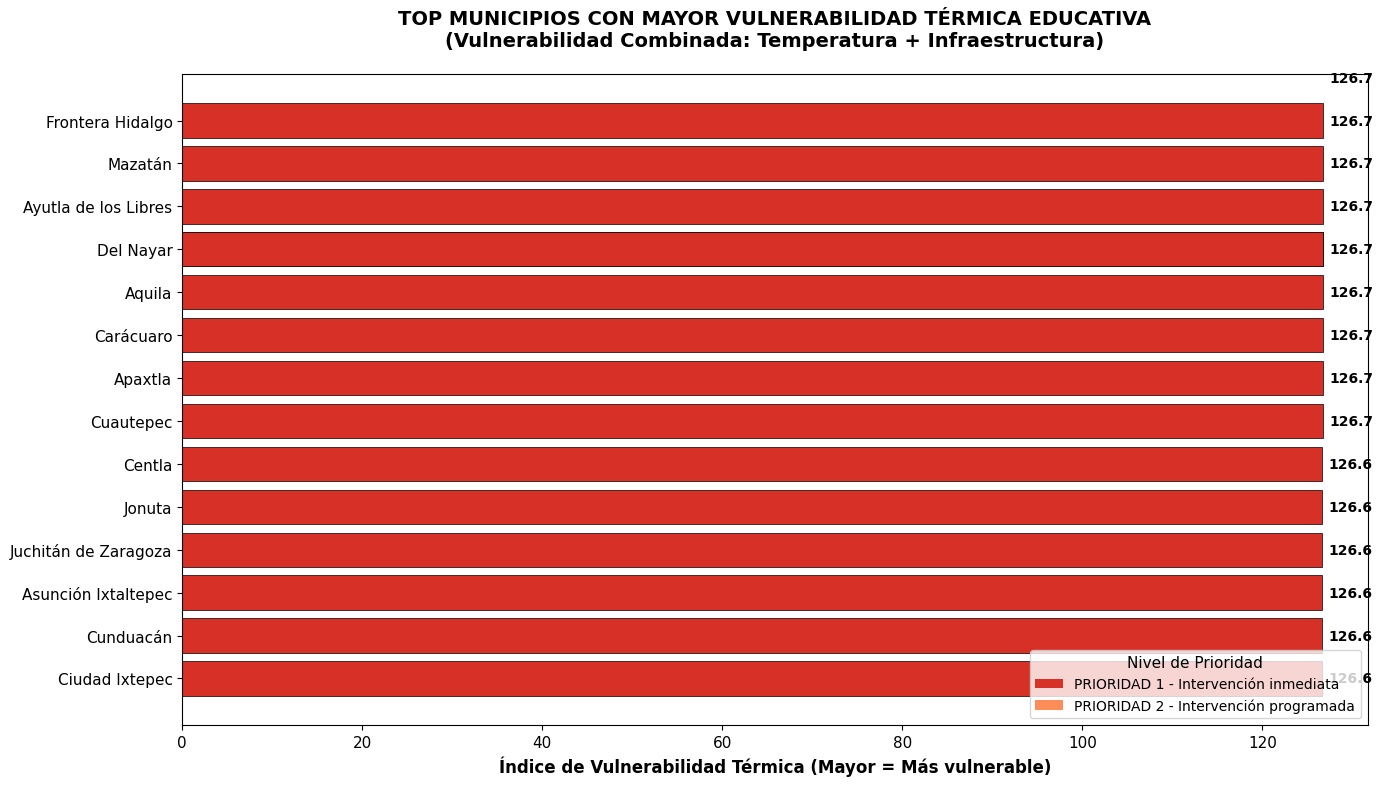

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))

# Filtramos por PRIORIDAD 1 y 2, y seleccionamos los top de vulnerabilidad térmica
df_impacto_plot = df_final[
    df_final['prioridad_intervencion'].str.contains('PRIORIDAD 1|PRIORIDAD 2')
].sort_values('vulnerabilidad_termica', ascending=False).head(15).copy()

# Asegurar que haya datos para plotear
if df_impacto_plot.empty:
    print("No hay municipios con Prioridad 1 o 2 para graficar.")
else:
    if 'Estado' in df_impacto_plot.columns:
        df_impacto_plot['nombre_municipio_estado'] = df_impacto_plot['Municipio'] + ' (' + df_impacto_plot['Estado'] + ')'
    elif 'NOM_MUN_CLEAN' in df_impacto_plot.columns:
        df_impacto_plot['nombre_municipio_estado'] = df_impacto_plot['NOM_MUN_CLEAN']
    else:
        df_impacto_plot['nombre_municipio_estado'] = df_impacto_plot['Municipio']

    df_impacto_plot = df_impacto_plot.sort_values('vulnerabilidad_termica', ascending=True)

    colores = []
    for prioridad in df_impacto_plot['prioridad_intervencion']:
        if 'PRIORIDAD 1' in prioridad:
            colores.append('#d73027') # Rojo oscuro
        elif 'PRIORIDAD 2' in prioridad:
            colores.append('#fc8d59') # Naranja
        elif 'PRIORIDAD 3' in prioridad:
            colores.append('#fee090') # Amarillo (Aunque no deberían aparecer con el filtro)
        else:
            colores.append('#e0f3f8') # Azul claro (Aunque no deberían aparecer con el filtro)

    bars = ax.barh(df_impacto_plot['nombre_municipio_estado'],
                   df_impacto_plot['vulnerabilidad_termica'], # Cambiado a vulnerabilidad_termica
                   color=colores,
                   edgecolor='black',
                   linewidth=0.5)

    # No se usan líneas de referencia fijas, ya que vulnerabilidad_termica es un índice compuesto
    # Podríamos usar líneas basadas en cuantiles si el usuario lo requiere

    for i, (idx, row) in enumerate(df_impacto_plot.iterrows()):
        ax.text(row['vulnerabilidad_termica'] + 0.8, i,
                f"{row['vulnerabilidad_termica']:.1f}", # Formato para vulnerabilidad
                va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Índice de Vulnerabilidad Térmica (Mayor = Más vulnerable)', fontsize=12, fontweight='bold')
    ax.set_title('TOP MUNICIPIOS CON MAYOR VULNERABILIDAD TÉRMICA EDUCATIVA\n(Vulnerabilidad Combinada: Temperatura + Infraestructura)',
                 fontsize=14, fontweight='bold', pad=20)

    legend_elements = [
        mpatches.Patch(facecolor='#d73027', label='PRIORIDAD 1 - Intervención inmediata'),
        mpatches.Patch(facecolor='#fc8d59', label='PRIORIDAD 2 - Intervención programada')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Nivel de Prioridad')

    ax.set_xlim(0, df_impacto_plot['vulnerabilidad_termica'].max() + 5)
    plt.tight_layout()


### Análisis de la Distribución de Temperaturas Medias Anuales por Nivel de Riesgo

Para obtener una visión más global y 'acumulativa' del problema, este histograma muestra cómo se distribuyen las temperaturas medias anuales entre todos los municipios de México, resaltando la cantidad de municipios que caen en cada categoría de riesgo térmico (CRÍTICO, ALTO, MEDIO, BAJO).

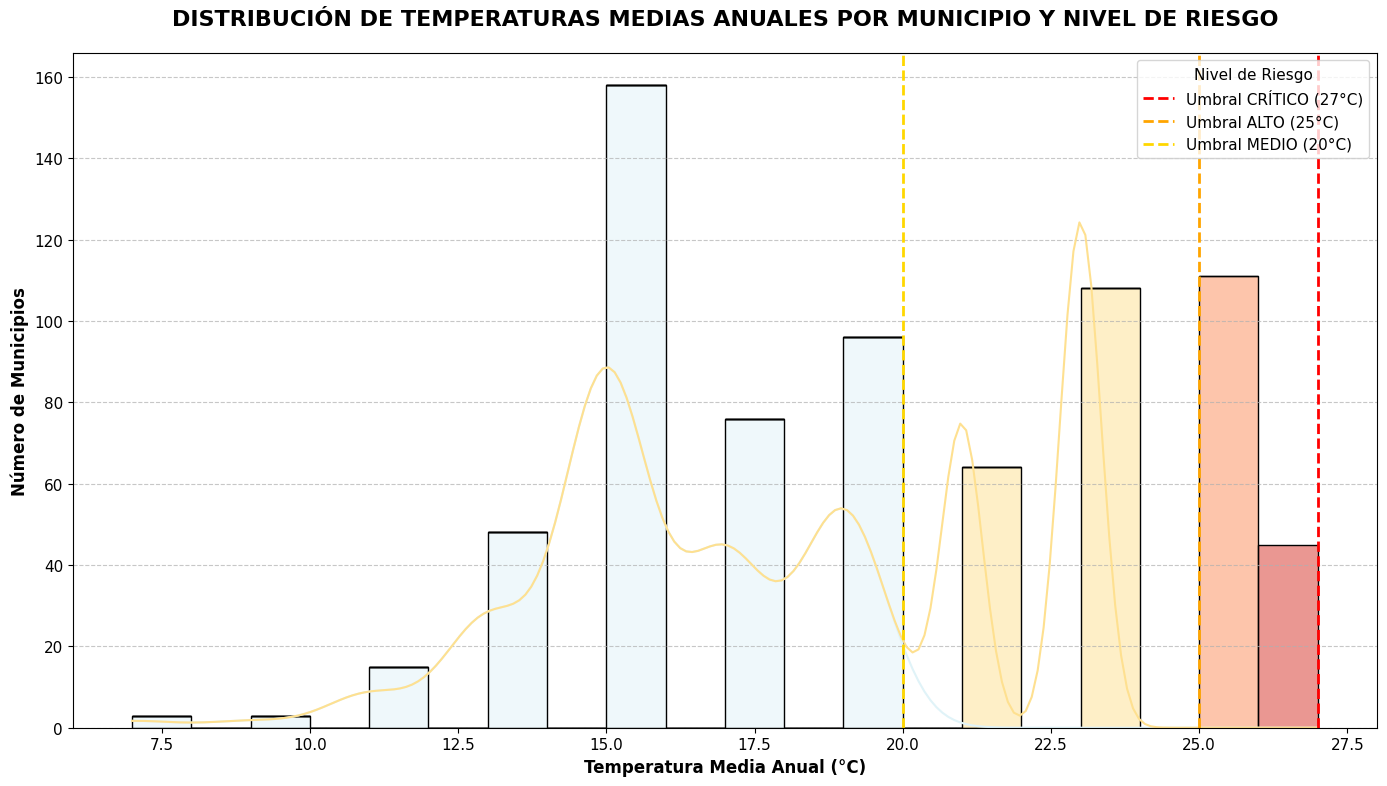

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Definir el orden de las categorías de riesgo para el plot
orden_riesgo = ['CRÍTICO', 'ALTO', 'MEDIO', 'BAJO']

# Definir una paleta de colores coherente con los umbrales definidos
paleta_riesgo = {
    'CRÍTICO': '#d73027',
    'ALTO': '#fc8d59',
    'MEDIO': '#fee090',
    'BAJO': '#e0f3f8'
}

sns.histplot(
    data=df_final.dropna(subset=['temp_media_anual', 'nivel_riesgo_termico']),
    x='temp_media_anual',
    hue='nivel_riesgo_termico',
    palette=paleta_riesgo,
    hue_order=orden_riesgo,
    multiple='stack', # Apila las barras por categoría de riesgo
    bins=20, # Número de "contenedores" para la temperatura
    edgecolor='black',
    kde=True # Añade una estimación de densidad del kernel
)

plt.axvline(x=27, color='red', linestyle='--', linewidth=2, label='Umbral CRÍTICO (27°C)')
plt.axvline(x=25, color='orange', linestyle='--', linewidth=2, label='Umbral ALTO (25°C)')
plt.axvline(x=20, color='gold', linestyle='--', linewidth=2, label='Umbral MEDIO (20°C)')

plt.title('DISTRIBUCIÓN DE TEMPERATURAS MEDIAS ANUALES POR MUNICIPIO Y NIVEL DE RIESGO',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Temperatura Media Anual (°C)', fontsize=12, fontweight='bold')
plt.ylabel('Número de Municipios', fontsize=12, fontweight='bold')
plt.legend(title='Nivel de Riesgo', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### El contexto educativo: avance en acceso, rezago en infraestructura
México ha expandido la cobertura educativa significativamente. Sin embargo, según datos del ciclo escolar 2022-2023 de la SEP-DGPPyEE:

#### Tabla 2: Brechas en infraestructura escolar básica a nivel nacional

In [60]:
data_table2 = {
    'Servicio básico': ['Agua potable', 'Lavamanos', 'Electricidad', 'Sanitarios'],
    '% Escuelas SIN servicio': ['21.5%', '18.1%', '8.8%', '4.2%'],
    'Equivalente en números absolutos*': ['~55,800 escuelas', '~47,000 escuelas', '~22,800 escuelas', '~10,900 escuelas']
}
df_table2 = pd.DataFrame(data_table2)
display(df_table2)
print("*Basado en 259,746 escuelas totales en México (ciclo 2022-2023)\nFuente: Sistema de Información y Gestión Educativa (SIGE), SEP-DGPPyEE")

,Servicio básico,% Escuelas SIN servicio,Equivalente en números absolutos*
0,Agua potable,21.5%,"~55,800 escuelas"
1,Lavamanos,18.1%,"~47,000 escuelas"
2,Electricidad,8.8%,"~22,800 escuelas"
3,Sanitarios,4.2%,"~10,900 escuelas"


*Basado en 259,746 escuelas totales en México (ciclo 2022-2023)
Fuente: Sistema de Información y Gestión Educativa (SIGE), SEP-DGPPyEE


La tensión central: El país tiene acceso educativo extendido, pero condiciones ambientales deterioradas para aprender. Las escuelas enfrentan un estrés térmico para el cual no fueron diseñadas.

### 2. DESARROLLO — Del concepto a los datos

#### Concepto nexus: Confort térmico escolar
Definición operacional: El confort térmico es el rango de condiciones ambientales (temperatura 20-26°C, humedad 40-60%, ventilación adecuada) donde un estudiante puede mantener concentración cognitiva sin distracción por estrés térmico.

Cadena causal del proyecto:
```
Temperaturas >35°C  +  Sin ventilación/Agua/Electricidad
           ↓
    Pérdida de confort térmico (estrés por calor)
           ↓
    Reducción de atención y rendimiento cognitivo
           ↓
    Brecha entre acceso educativo y aprendizaje efectivo
```

#### Desigualdad territorial: La brecha ODS 4-ODS 13
Los datos revelan que las carencias no se distribuyen uniformemente. Según CONEVAL y SEP-DGPPyEE:

#### Tabla 3: Desigualdad en infraestructura por tipo de escuela (2022-2023)

In [61]:
data_table3 = {
    'Tipo de escuela': ['Escuelas comunitarias', 'Primarias indígenas', 'Primarias generales públicas', 'Secundarias generales'],
    'Sin agua potable': ['>50%', '43.7%', '16.3%', 'Datos inferiores'],
    'Sin electricidad': ['30.33%', 'Datos no disponibles', '3.9%', 'Datos inferiores'],
    'Sin infraestructura adaptada': ['~98.8%', '~94%', '76.2%', '74.3%']
}
df_table3 = pd.DataFrame(data_table3)
display(df_table3)
print("Hallazgo crítico: Las escuelas en localidades rurales, indígenas y de alta marginación —que ya enfrentan brechas de asistencia de 5.4 puntos porcentuales respecto a zonas urbanas— son precisamente las que peor infraestructura térmica tienen.\nFuente: Sistema de Información y Gestión Educativa (SIGE), SEP-DGPPyEE; CONEVAL")

,Tipo de escuela,Sin agua potable,Sin electricidad,Sin infraestructura adaptada
0,Escuelas comunitarias,>50%,30.33%,~98.8%
1,Primarias indígenas,43.7%,Datos no disponibles,~94%
2,Primarias generales públicas,16.3%,3.9%,76.2%
3,Secundarias generales,Datos inferiores,Datos inferiores,74.3%


Hallazgo crítico: Las escuelas en localidades rurales, indígenas y de alta marginación —que ya enfrentan brechas de asistencia de 5.4 puntos porcentuales respecto a zonas urbanas— son precisamente las que peor infraestructura térmica tienen.
Fuente: Sistema de Información y Gestión Educativa (SIGE), SEP-DGPPyEE; CONEVAL


La siguiente gráfica muestra la infraestructura escolar en las zonas identificadas con mayor prioridad de intervención (Prioridad 1 y 2), comparando el porcentaje de escuelas con y sin agua potable e infraestructura adaptada.

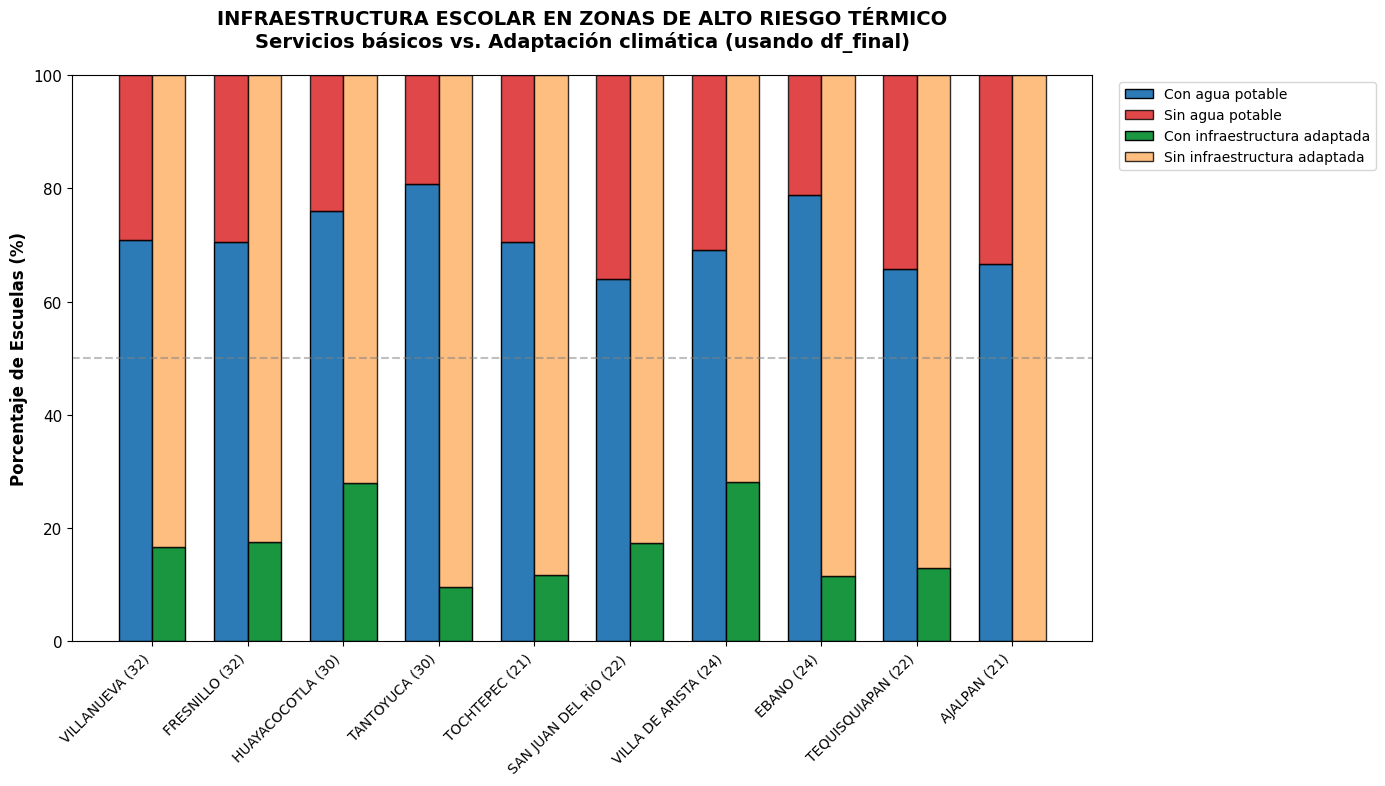

In [62]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

df_prioritarios = df_final[df_final['prioridad_intervencion'].str.contains('PRIORIDAD 1|PRIORIDAD 2')].copy()
df_prioritarios = df_prioritarios.sort_values('vulnerabilidad_termica', ascending=True).head(10) # Top 10 para mejor visualización

municipios = (df_prioritarios['Municipio'] + ' (' + df_prioritarios['cve_mun_full'].str[:2] + ')').tolist()
con_agua = df_prioritarios['agua_potable_pct'].values
sin_agua = 100 - df_prioritarios['agua_potable_pct'].values
con_adaptada = df_prioritarios['infra_adaptada_pct'].values
sin_adaptada = 100 - df_prioritarios['infra_adaptada_pct'].values

x = np.arange(len(municipios))
width = 0.35

bars1 = ax.bar(x - width/2, con_agua, width, label='Con agua potable', color='#2c7bb6', edgecolor='black')
bars2 = ax.bar(x - width/2, sin_agua, width, bottom=con_agua, label='Sin agua potable', color='#d7191c', edgecolor='black', alpha=0.8)
bars3 = ax.bar(x + width/2, con_adaptada, width, label='Con infraestructura adaptada', color='#1a9641', edgecolor='black')
bars4 = ax.bar(x + width/2, sin_adaptada, width, bottom=con_adaptada, label='Sin infraestructura adaptada', color='#fdae61', edgecolor='black', alpha=0.8)

ax.set_ylabel('Porcentaje de Escuelas (%)', fontsize=12, fontweight='bold')
ax.set_title('INFRAESTRUCTURA ESCOLAR EN ZONAS DE ALTO RIESGO TÉRMICO\nServicios básicos vs. Adaptación climática (usando df_final)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(municipios, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### El cruce crítico: Temperatura + Infraestructura
Metodología: Cruzar datos de CONAGUA (temperatura máxima municipal) con INEGI-CEMABE (infraestructura escolar) permite identificar zonas de vulnerabilidad térmica educativa.

#### Tabla 4: Matriz de riesgo de confort térmico escolar

In [63]:
data_table4 = {
    'Zona': ['Alta vulnerabilidad', 'Vulnerabilidad media', 'Vulnerabilidad baja'],
    'Características climáticas': ['>40°C, baja humedad', '35-40°C, variada', '<35°C, estable'],
    'Infraestructura típica': ['Escuelas comunitarias sin agua/eléctricas', 'Primarias rurales con servicios básicos irregulares', 'Escuelas urbanas con ventilación y agua garantizada'],
    'Riesgo de confort térmico': ['CRÍTICO', 'ALTO', 'MODERADO']
}


,Zona,Características climáticas,Infraestructura típica,Riesgo de confort térmico
0,Alta vulnerabilidad,">40°C, baja humedad",Escuelas comunitarias sin agua/eléctricas,CRÍTICO
1,Vulnerabilidad media,"35-40°C, variada",Primarias rurales con servicios básicos irregu...,ALTO
2,Vulnerabilidad baja,"<35°C, estable",Escuelas urbanas con ventilación y agua garant...,MODERADO


El siguiente gráfico de dispersión ilustra la relación entre la temperatura media anual y el índice de infraestructura escolar para los municipios en tu `df_final`, usando el tamaño de los puntos para representar el número de escuelas y el color para indicar la prioridad de intervención.

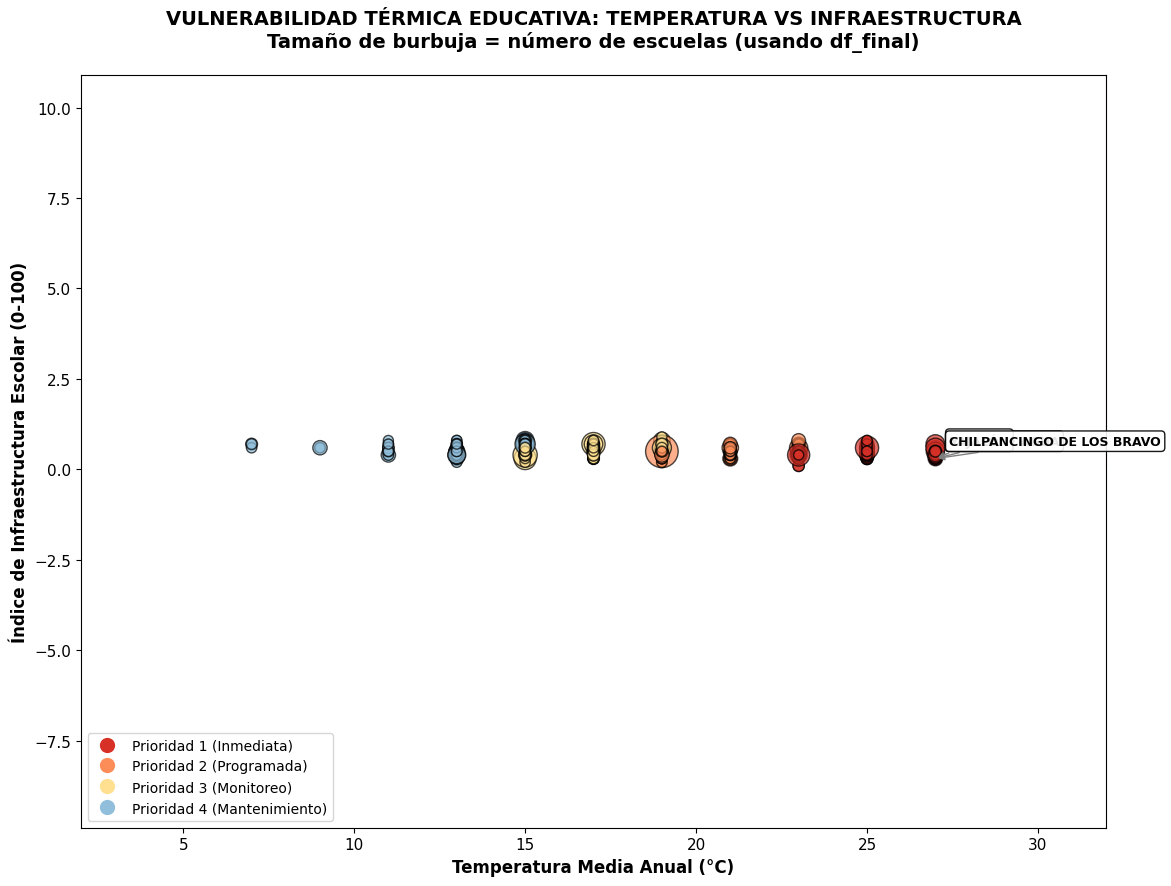

In [64]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

fig, ax = plt.subplots(figsize=(12, 9))

df_scatter_plot = df_final.dropna(subset=['temp_media_anual', 'indice_infra_sep', 'Escuelas', 'vulnerabilidad_termica', 'prioridad_intervencion']).copy()

colores_scatter = []
for prioridad in df_scatter_plot['prioridad_intervencion']:
    if 'PRIORIDAD 1' in prioridad:
        colores_scatter.append('#d73027')
    elif 'PRIORIDAD 2' in prioridad:
        colores_scatter.append('#fc8d59')
    elif 'PRIORIDAD 3' in prioridad:
        colores_scatter.append('#fee090')
    else:
        colores_scatter.append('#91bfdb')

tamanos = (df_scatter_plot['Escuelas'] / df_scatter_plot['Escuelas'].max()) * 500 + 50

scatter = ax.scatter(df_scatter_plot['temp_media_anual'],
                     df_scatter_plot['indice_infra_sep'],
                     c=colores_scatter,
                     s=tamanos,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=1)

top_criticos = df_scatter_plot.nlargest(3, 'vulnerabilidad_termica')
for idx, row in top_criticos.iterrows():
    ax.annotate(row['Municipio'],
                (row['temp_media_anual'], row['indice_infra_sep']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.axvline(x=40, color='red', linestyle='--', alpha=0.5)
ax.fill_between([40, df_scatter_plot['temp_media_anual'].max() + 5], 0, 50, alpha=0.15, color='red')

ax.set_xlabel('Temperatura Media Anual (°C)', fontsize=12, fontweight='bold')
ax.set_ylabel('Índice de Infraestructura Escolar (0-100)', fontsize=12, fontweight='bold')
ax.set_title('VULNERABILIDAD TÉRMICA EDUCATIVA: TEMPERATURA VS INFRAESTRUCTURA\nTamaño de burbuja = número de escuelas (usando df_final)',
             fontsize=14, fontweight='bold', pad=20)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', markersize=12, label='Prioridad 1 (Inmediata)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#fc8d59', markersize=12, label='Prioridad 2 (Programada)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#fee090', markersize=12, label='Prioridad 3 (Monitoreo)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#91bfdb', markersize=12, label='Prioridad 4 (Mantenimiento)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)

ax.set_xlim(df_scatter_plot['temp_media_anual'].min() - 5, df_scatter_plot['temp_media_anual'].max() + 5)
ax.set_ylim(df_scatter_plot['indice_infra_sep'].min() - 10, df_scatter_plot['indice_infra_sep'].max() + 10)

plt.tight_layout()
plt.show()

### 3. CIERRE — Hallazgos y llamado a la acción

#### Insight principal
México ha avanzado en el ODS 4 (acceso a educación), pero podría estar rezagándose en garantizar las condiciones del ODS 4.a (instalaciones adecuadas) en un contexto que exige cumplimiento del ODS 13 (adaptación al clima).

#### Recomendaciones accionables para tomadores de decisión
**Prioridad 1: Intervención territorial focalizada**
Dónde: Municipios con temperatura máxima >38°C + escuelas comunitarias/indígenas
Qué: Instalación de sistemas de ventilación, techos reflectivos, garantía de agua potable
Por qué: Cumplimiento simultáneo de Meta 4.a (infraestructura) y Meta 13.1 (adaptación)

**Prioridad 2: Indicadores de seguimiento**

#### Tabla 6: Propuesta de indicadores de monitoreo para política pública

In [66]:
data_table6 = {
    'Indicador': ['% Escuelas con confort térmico adecuado', 'Brecha de infraestructura en zonas >40°C', 'Asistencia escolar vs. temperatura máxima', 'Inversión en infraestructura resiliente al calor'],
    'Fuente de datos': ['CEMABE + CONAGUA', 'SEP-DGPPyEE', 'ENIGH + CONAGUA', 'SHCP + SEP'],
    'Frecuencia de medición': ['Anual', 'Por ciclo escolar', 'Bienal', 'Anual']
}
df_table6 = pd.DataFrame(data_table6)
display(df_table6)

,Indicador,Fuente de datos,Frecuencia de medición
0,% Escuelas con confort térmico adecuado,CEMABE + CONAGUA,Anual
1,Brecha de infraestructura en zonas >40°C,SEP-DGPPyEE,Por ciclo escolar
2,Asistencia escolar vs. temperatura máxima,ENIGH + CONAGUA,Bienal
3,Inversión en infraestructura resiliente al calor,SHCP + SEP,Anual


**Prioridad 3: Inversión en resiliencia climática educativa**
Redireccionar recursos del Programa E047 (mantenimiento infraestructura) hacia zonas de estrés térmico identificadas en el cruce de datos
Establecer estándar de "escuela resiliente al calor": ventilación cruzada, sombra, agua garantizada

### 4. FRASE GUÍA DEL PROYECTO

"No todas las escuelas en México cuentan con la infraestructura necesaria para mantener condiciones de confort térmico, elemento fundamental para garantizar entornos de aprendizaje efectivo. El cumplimiento del ODS 4 requiere avanzar en el ODS 4.a (instalaciones adecuadas) en un contexto que demanda adaptación climática del ODS 13."

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los 10 municipios con la temperatura media anual más alta
df_top_temp = df_final.nlargest(10, 'temp_media_anual')

# Preparar los datos para la gráfica
df_plot_infra = df_top_temp[['Municipio', 'agua_potable_pct', 'electricidad_pct']].copy()

# Convertir a formato 'long' para Seaborn si es necesario, o manejar con Matplotlib
# Para un gr\u00e1fico de barras agrupadas simple, se puede hacer directamente con Matplotlib

print("Datos preparados para el gr\u00e1fico de infraestructura en municipios de alta temperatura.")
display(df_plot_infra)

Datos preparados para el gráfico de infraestructura en municipios de alta temperatura.


,Municipio,agua_potable_pct,electricidad_pct
17,CAMPECHE,80.5,91.2
18,CANDELARIA,88.8,86.2
21,DZITBALCHÉ,46.5,83.7
41,COLIMA,97.4,99.3
45,IXTLAHUACÁN,88.2,94.1
58,CHAMULA,52.5,93.2
70,JUÁREZ,58.8,89.7
84,SALTO DE AGUA,50.0,93.8
103,YAJALÓN,15.2,87.0
184,ACAPULCO DE JUÁREZ,73.6,95.4


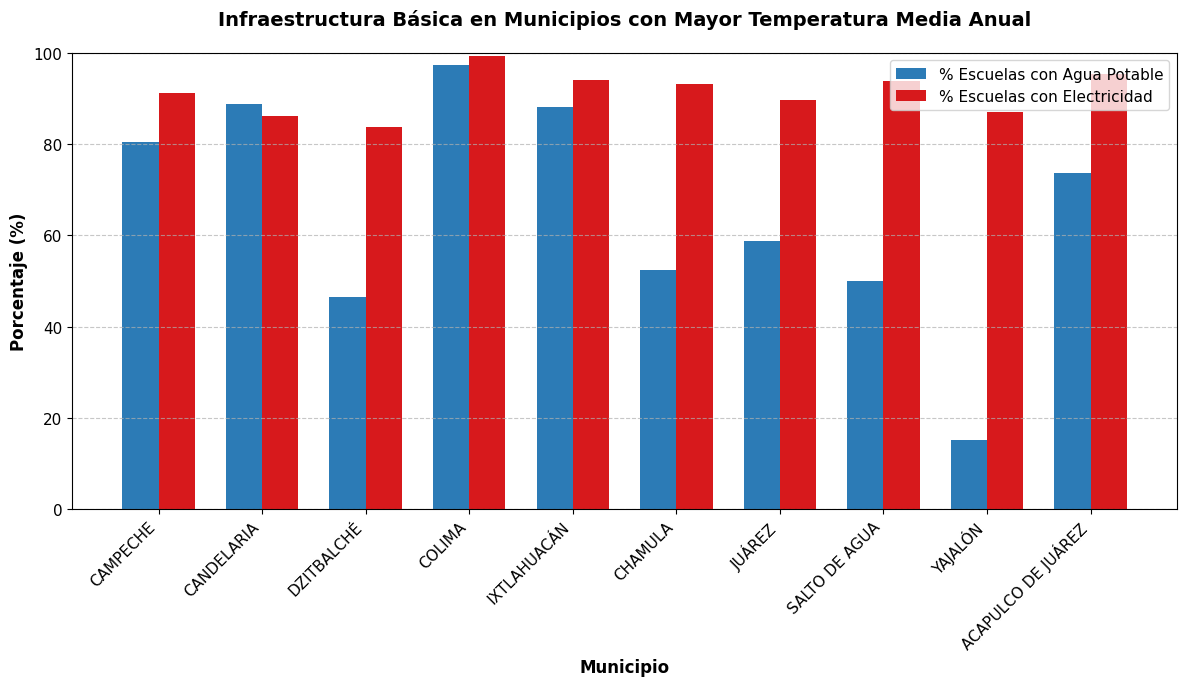

In [71]:
import numpy as np

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(12, 7))

# Definir el ancho de las barras
bar_width = 0.35

# Crear índices para las barras
ind = np.arange(len(df_plot_infra['Municipio']))

# Barras para agua_potable_pct
rects1 = ax.bar(ind - bar_width/2, df_plot_infra['agua_potable_pct'], bar_width, label='% Escuelas con Agua Potable', color='#2c7bb6')

# Barras para electricidad_pct
rects2 = ax.bar(ind + bar_width/2, df_plot_infra['electricidad_pct'], bar_width, label='% Escuelas con Electricidad', color='#d7191c')

# Añadir etiquetas, título y leyenda
ax.set_xlabel('Municipio', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_title('Infraestructura Básica en Municipios con Mayor Temperatura Media Anual', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(ind)
ax.set_xticklabels(df_plot_infra['Municipio'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100) # Porcentajes van de 0 a 100
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para el gráfico de dispersión
# Seleccionamos las columnas relevantes y eliminamos NaN para asegurar el plot
df_scatter_data = df_final[['temp_media_anual', 'asistencia_primaria_pct', 'prioridad_intervencion', 'Escuelas']].dropna().copy()

# Opcional: Si 'asistencia_primaria_pct' tiene pocos datos, se podría usar 'asistencia_15_17_pct'
# En este caso, la instrucción pide 'asistencia_primaria_pct' o 'asistencia_15_17_pct'
# Asumimos que asistencia_primaria_pct es la preferida si está disponible y tiene datos

print("Datos preparados para el gráfico de dispersión de temperatura vs. asistencia escolar.")
display(df_scatter_data.head())

Datos preparados para el gráfico de dispersión de temperatura vs. asistencia escolar.


,temp_media_anual,asistencia_primaria_pct,prioridad_intervencion,Escuelas
0,15.0,97.1,PRIORIDAD 4 - Mantenimiento preventivo,42
1,15.0,95.7,PRIORIDAD 4 - Mantenimiento preventivo,2
2,19.0,96.3,PRIORIDAD 3 - Monitoreo constante,1
3,15.0,95.3,PRIORIDAD 4 - Mantenimiento preventivo,3
4,15.0,96.6,PRIORIDAD 4 - Mantenimiento preventivo,1


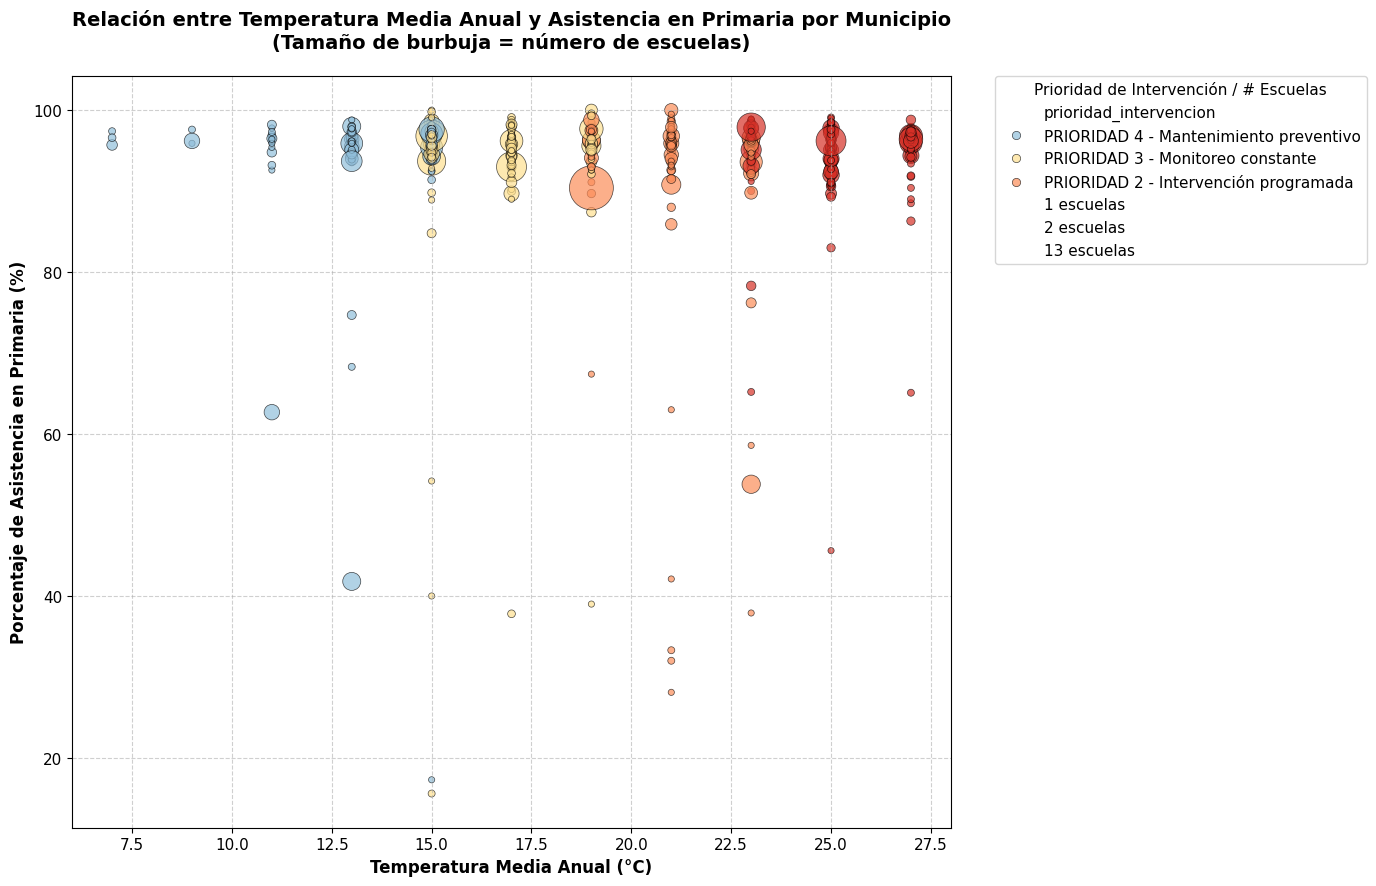

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a color palette for 'prioridad_intervencion'
color_palette = {
    'PRIORIDAD 1 - Intervención inmediata': '#d73027',    # Rojo oscuro
    'PRIORIDAD 2 - Intervención programada': '#fc8d59',    # Naranja
    'PRIORIDAD 3 - Monitoreo constante': '#fee090',      # Amarillo
    'PRIORIDAD 4 - Mantenimiento preventivo': '#91bfdb' # Azul claro
}

plt.figure(figsize=(14, 9))

# Crear el scatter plot
scatter = sns.scatterplot(
    data=df_scatter_data,
    x='temp_media_anual',
    y='asistencia_primaria_pct',
    hue='prioridad_intervencion',
    size='Escuelas', # Tamaño de los puntos basado en el número de escuelas
    sizes=(20, 1000), # Rango de tamaño de los puntos
    palette=color_palette, # Colores basados en la prioridad de intervención
    alpha=0.7,
    edgecolor='black', # Borde para mejor visibilidad
    linewidth=0.5
)

# Añadir etiquetas y título
plt.xlabel('Temperatura Media Anual (°C)', fontsize=12, fontweight='bold')
plt.ylabel('Porcentaje de Asistencia en Primaria (%)', fontsize=12, fontweight='bold')
plt.title('Relación entre Temperatura Media Anual y Asistencia en Primaria por Municipio\n(Tamaño de burbuja = número de escuelas)', fontsize=14, fontweight='bold', pad=20)

# Mostrar leyenda para el tamaño de las burbujas
handles, labels = scatter.get_legend_handles_labels()

# Crear una leyenda personalizada para los tamaños
num_schools_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=f'{int(s)} escuelas', markersize=np.sqrt(s/np.max(df_scatter_data['Escuelas']) * 1000 + 20)/2) # Ajustar para una escala visual
    for s in df_scatter_data['Escuelas'].quantile([0.1, 0.5, 0.9]).round().astype(int).sort_values().unique()
]

# Combinar leyendas
plt.legend(handles=handles[0:len(color_palette)] + num_schools_legend_elements,
           labels=labels[0:len(color_palette)] + [f'{int(s)} escuelas' for s in df_scatter_data['Escuelas'].quantile([0.1, 0.5, 0.9]).round().astype(int).sort_values().unique()],
           title='Prioridad de Intervención / # Escuelas',
           bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()